# Train a separate MPNN global scene-graph refiner

This notebook assumes you already generated per-frame `frame-*.relation.json` files and trained a `RelationHead`.

Pipeline:

1. Load per-frame object features and `query_to_object_id`.
2. Load frozen `RelationHead`.
3. Predict frame-level relation logits.
4. Aggregate them into one graph per scan.
5. Train a message-passing neural network to refine global scan relations using `relationships.json`.

In [31]:
import json
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

In [32]:
# =========================
# Config
# =========================
scans_root = Path("/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans")
relationships_json_path = Path("/home/abdou/Projects/Python/RTSGS/Datasets/3DSSG/3DSSG/relationships.json")
relationship_names_path = relationships_json_path.with_name("relationships.txt")

relation_head_ckpt_path = scans_root / "relation_branch_hard_negative_bce.pt"
mpgnn_save_path = scans_root / "global_scene_graph_mpgnn.pt"

train_glob = "frame-*.relation.json"

# Use None for all scans/frames.
max_scans = None
max_frames_per_scan = None

seed = 42
train_ratio = 0.9
num_epochs = 30
learning_rate = 1e-4
weight_decay = 1e-4
threshold = 0.5

# Negative sampling for global relation matrix.
neg_ratio = 50
min_negatives = 1000

# Freeze relation head first. Recommended.
freeze_relation_head = True

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [33]:
# =========================
# Load relationship names and global labels
# =========================
if not scans_root.exists():
    raise FileNotFoundError(scans_root)
if not relationships_json_path.exists():
    raise FileNotFoundError(relationships_json_path)
if not relationship_names_path.exists():
    raise FileNotFoundError(relationship_names_path)

with open(relationships_json_path, "r", encoding="utf-8") as f:
    relationships_data = json.load(f)

with open(relationship_names_path, "r", encoding="utf-8") as f:
    relation_names = [line.strip() for line in f if line.strip()]

num_rel_classes_from_txt = len(relation_names)

relationships_by_scan = {
    entry["scan"]: entry.get("relationships", [])
    for entry in relationships_data.get("scans", [])
    if entry.get("scan") is not None
}

print("num relation classes:", num_rel_classes_from_txt)
print("num scans in relationships.json:", len(relationships_by_scan))

num relation classes: 41
num scans in relationships.json: 1335


In [34]:
# =========================
# RelationHead definition: same as your original notebook
# =========================
class RelationHead(nn.Module):
    def __init__(self, hidden_dim=512, num_rel_classes=41, nhead=8, num_rel_layers=3):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=1024,
            batch_first=True,
            dropout=0.1,
        )

        self.rel_transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_rel_layers,
        )

        self.rel_predictor = nn.Sequential(
            nn.Linear(hidden_dim * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_rel_classes),
        )

    def forward(self, object_features):
        # object_features: [B, K, D]
        refined = self.rel_transformer(object_features)

        bsz, k, d = refined.shape

        q_i = refined.unsqueeze(2).expand(bsz, k, k, d)
        q_j = refined.unsqueeze(1).expand(bsz, k, k, d)

        pair_features = torch.cat(
            [q_i, q_j, q_i - q_j, q_i * q_j],
            dim=-1,
        )

        rel_logits = self.rel_predictor(pair_features)  # [B, K, K, R]
        return rel_logits

In [35]:
# =========================
# MPNN global scene graph refiner
# =========================
class GlobalSceneGraphMPNN(nn.Module):
    def __init__(self, node_dim, rel_dim, hidden_dim=512, num_layers=3, dropout=0.1):
        super().__init__()

        self.node_proj = nn.Linear(node_dim, hidden_dim)
        self.edge_proj = nn.Linear(rel_dim, hidden_dim)

        self.message_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.node_update = nn.GRUCell(hidden_dim, hidden_dim)

        self.edge_out = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, rel_dim),
        )

        self.num_layers = num_layers

    def forward(self, node_feats, edge_feats):
        """
        node_feats: [N, D]
        edge_feats: [N, N, R] initial global relation logits from RelationHead
        returns:    [N, N, R] refined global relation logits
        """
        h = self.node_proj(node_feats)       # [N, H]
        e = self.edge_proj(edge_feats)       # [N, N, H]

        N, H = h.shape
        if N == 0:
            raise RuntimeError("Cannot run MPNN on empty graph.")

        for _ in range(self.num_layers):
            hi = h.unsqueeze(1).expand(N, N, H)
            hj = h.unsqueeze(0).expand(N, N, H)

            msg_input = torch.cat([hi, hj, e], dim=-1)
            messages = self.message_mlp(msg_input)  # [N, N, H]

            # aggregate incoming messages for every destination node
            incoming = messages.sum(dim=0) / max(N, 1)
            h = self.node_update(incoming, h)

        hi = h.unsqueeze(1).expand(N, N, H)
        hj = h.unsqueeze(0).expand(N, N, H)
        edge_input = torch.cat([hi, hj, e], dim=-1)

        return self.edge_out(edge_input)

In [36]:
# =========================
# Dataset: each item is one scan and its valid frame relation JSON files
# =========================
import re
from pathlib import Path
from torch.utils.data import Dataset

class ScanRelationJsonDataset(Dataset):
    def __init__(
        self,
        scans_root,
        relationships_by_scan,
        train_glob="frame-*.relation.json",
        max_scans=None,
        max_frames_per_scan=None,
    ):
        self.scans_root = Path(scans_root)
        self.relationships_by_scan = relationships_by_scan
        self.train_glob = train_glob
        self.max_frames_per_scan = max_frames_per_scan

        # Only accepts:
        # frame-000000.relation.json
        # frame-123.relation.json
        #
        # Rejects:
        # frame-000000.rendered.relation.json
        frame_relation_pattern = re.compile(r"^frame-\d+\.relation\.json$")

        scan_items = []

        for scan_dir in sorted(self.scans_root.iterdir()):
            if not scan_dir.is_dir():
                continue

            scan_id = scan_dir.name

            if scan_id not in self.relationships_by_scan:
                continue

            sequence_dir = scan_dir / "sequence"

            if not sequence_dir.exists():
                continue

            frame_jsons = sorted([
                p for p in sequence_dir.glob(train_glob)
                if frame_relation_pattern.match(p.name)
            ])

            if self.max_frames_per_scan is not None:
                frame_jsons = frame_jsons[:self.max_frames_per_scan]

            if len(frame_jsons) == 0:
                continue

            scan_items.append({
                "scan_id": scan_id,
                "frame_jsons": frame_jsons,
            })

        if max_scans is not None:
            scan_items = scan_items[:max_scans]

        self.items = scan_items

        print(f"Loaded {len(self.items)} scans.")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]

        return {
            "scan_id": item["scan_id"],
            "frame_jsons": [str(p) for p in item["frame_jsons"]],
            "relationships": self.relationships_by_scan[item["scan_id"]],
        }


def collate_one_scan(batch):
    return batch[0]

In [37]:
# =========================
# Build one global scan graph from all frame relation JSONs
# =========================
def build_global_graph_from_scan_item(scan_item, relation_head, device):
    """
    Returns:
        node_feats: [N, D]
        edge_feats: [N, N, R] aggregated frame relation logits
        targets:    [N, N, R] global labels from relationships.json
        object_ids: list of global scan object ids
    """
    relation_head.eval()

    node_sum = {}
    node_count = defaultdict(int)
    edge_sum = {}
    edge_count = defaultdict(int)

    rel_dim = None
    node_dim = None

    for frame_json in scan_item["frame_jsons"]:
        with open(frame_json, "r", encoding="utf-8") as f:
            sample = json.load(f)

        if "query_to_object_id" not in sample:
            raise KeyError(
                f"{frame_json} has no query_to_object_id. Regenerate relation JSON files first."
            )

        object_features = torch.tensor(sample["object_features"], dtype=torch.float32, device=device)  # [K, D]
        q_to_obj = [int(x) for x in sample["query_to_object_id"]]

        K, D = object_features.shape
        node_dim = D

        with torch.set_grad_enabled(not freeze_relation_head):
            frame_logits = relation_head(object_features.unsqueeze(0))[0]  # [K, K, R]

        rel_dim = int(frame_logits.shape[-1])

        # accumulate node features by global scan object id
        for q, obj_id in enumerate(q_to_obj):
            if obj_id < 0:
                continue

            feat = object_features[q]
            if obj_id not in node_sum:
                node_sum[obj_id] = feat.detach() if freeze_relation_head else feat
            else:
                node_sum[obj_id] = node_sum[obj_id] + feat
            node_count[obj_id] += 1

        # accumulate edge logits by global scan object pair
        for i in range(K):
            src_id = q_to_obj[i]
            if src_id < 0:
                continue
            for j in range(K):
                dst_id = q_to_obj[j]
                if dst_id < 0 or src_id == dst_id:
                    continue

                key = (src_id, dst_id)
                value = frame_logits[i, j]
                if freeze_relation_head:
                    value = value.detach()

                if key not in edge_sum:
                    edge_sum[key] = value
                else:
                    edge_sum[key] = edge_sum[key] + value
                edge_count[key] += 1

    object_ids = sorted(node_sum.keys())
    if len(object_ids) == 0:
        raise RuntimeError(f"Scan {scan_item['scan_id']} has no mapped query_to_object_id objects.")

    obj_to_idx = {obj_id: idx for idx, obj_id in enumerate(object_ids)}
    N = len(object_ids)

    node_feats = torch.zeros(N, node_dim, dtype=torch.float32, device=device)
    edge_feats = torch.zeros(N, N, rel_dim, dtype=torch.float32, device=device)
    targets = torch.zeros(N, N, rel_dim, dtype=torch.float32, device=device)

    for obj_id in object_ids:
        idx = obj_to_idx[obj_id]
        node_feats[idx] = node_sum[obj_id] / max(node_count[obj_id], 1)

    for (src_id, dst_id), value in edge_sum.items():
        if src_id not in obj_to_idx or dst_id not in obj_to_idx:
            continue
        i = obj_to_idx[src_id]
        j = obj_to_idx[dst_id]
        edge_feats[i, j] = value / max(edge_count[(src_id, dst_id)], 1)

    for rel in scan_item["relationships"]:
        if not isinstance(rel, (list, tuple)) or len(rel) < 3:
            continue
        try:
            src_id = int(rel[0])
            dst_id = int(rel[1])
            rel_id = int(rel[2])
        except (TypeError, ValueError):
            continue

        if src_id in obj_to_idx and dst_id in obj_to_idx and 0 <= rel_id < rel_dim:
            targets[obj_to_idx[src_id], obj_to_idx[dst_id], rel_id] = 1.0

    # Do not train self edges.
    eye = torch.eye(N, dtype=torch.bool, device=device)
    targets[eye] = 0.0
    edge_feats[eye] = 0.0

    return node_feats, edge_feats, targets, object_ids

In [38]:
# =========================
# Loss mask: positives + hard negatives
# =========================
def make_loss_mask(logits, targets, neg_ratio=50, min_negatives=1000):
    with torch.no_grad():
        pos_mask = targets == 1
        neg_mask = targets == 0

        num_pos = int(pos_mask.sum().item())
        num_neg = int(neg_mask.sum().item())

        if num_neg == 0:
            return pos_mask

        keep_neg = min(max(num_pos * neg_ratio, min_negatives), num_neg)

        probs = torch.sigmoid(logits)
        neg_scores = probs[neg_mask]
        neg_indices = neg_mask.nonzero(as_tuple=False)

        hard_ids = torch.topk(
            neg_scores,
            k=min(keep_neg, neg_scores.numel()),
            largest=True,
        ).indices

        mask = pos_mask.clone()
        selected = neg_indices[hard_ids]
        mask[selected[:, 0], selected[:, 1], selected[:, 2]] = True

        return mask


def compute_metrics(logits, targets, threshold=0.5):
    with torch.no_grad():
        preds = (torch.sigmoid(logits) > threshold)
        t = targets.bool()

        tp = ((preds == 1) & (t == 1)).sum().item()
        fp = ((preds == 1) & (t == 0)).sum().item()
        fn = ((preds == 0) & (t == 1)).sum().item()

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        return precision, recall, f1, tp, fp, fn

In [39]:
# =========================
# Load trained RelationHead checkpoint
# =========================
ckpt = torch.load(relation_head_ckpt_path, map_location=device)

hidden_dim = int(ckpt.get("hidden_dim", ckpt.get("object_feature_dim", 512)))
num_rel_classes = int(ckpt.get("num_rel_classes", num_rel_classes_from_txt))

relation_head = RelationHead(
    hidden_dim=hidden_dim,
    num_rel_classes=num_rel_classes,
    nhead=8,
    num_rel_layers=3,
).to(device)

relation_head.load_state_dict(ckpt["model_state_dict"])

if freeze_relation_head:
    relation_head.eval()
    for p in relation_head.parameters():
        p.requires_grad = False
else:
    relation_head.train()
    for p in relation_head.parameters():
        p.requires_grad = True

print("Loaded RelationHead:")
print("hidden_dim:", hidden_dim)
print("num_rel_classes:", num_rel_classes)
print("frozen:", freeze_relation_head)

Loaded RelationHead:
hidden_dim: 512
num_rel_classes: 41
frozen: True


In [40]:
# =========================
# Create train/val scan loaders
# =========================
full_dataset = ScanRelationJsonDataset(
    scans_root=scans_root,
    relationships_by_scan=relationships_by_scan,
    train_glob=train_glob,
    max_scans=max_scans,
    max_frames_per_scan=max_frames_per_scan,
)

if len(full_dataset) == 0:
    raise RuntimeError("No scans found. Check scans_root and generated frame-*.relation.json files.")

train_size = max(1, int(len(full_dataset) * train_ratio))
val_size = len(full_dataset) - train_size

if val_size == 0 and len(full_dataset) > 1:
    train_size = len(full_dataset) - 1
    val_size = 1

generator = torch.Generator().manual_seed(seed)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_one_scan)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_scan) if val_size > 0 else None

print("total scans:", len(full_dataset))
print("train scans:", len(train_dataset))
print("val scans:", val_size)
print("example:", full_dataset[0]["scan_id"], "frames:", len(full_dataset[0]["frame_jsons"]))

Loaded 26 scans.
total scans: 26
train scans: 23
val scans: 3
example: 0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca frames: 523


In [ ]:
# =========================
# Initialize MPNN and optimizer
# =========================
mpgnn = GlobalSceneGraphMPNN(
    node_dim=hidden_dim,
    rel_dim=num_rel_classes,
    hidden_dim=512,
    num_layers=3,
    dropout=0.1,
).to(device)

params = list(mpgnn.parameters())
if not freeze_relation_head:
    params += list(relation_head.parameters())

optimizer = torch.optim.AdamW(params, lr=learning_rate, weight_decay=weight_decay)
criterion = nn.BCEWithLogitsLoss(reduction="none")

print("MPNN params:", sum(p.numel() for p in mpgnn.parameters()))

MPNN params: 3717673


In [41]:
# =========================
# Optional sanity check on one scan
# =========================
scan_item = full_dataset[0]
node_feats, edge_feats, targets, object_ids = build_global_graph_from_scan_item(scan_item, relation_head, device)

print("scan:", scan_item["scan_id"])
print("num objects:", len(object_ids))
print("node_feats:", tuple(node_feats.shape))
print("edge_feats:", tuple(edge_feats.shape))
print("targets:", tuple(targets.shape))
print("positive global relations:", int(targets.sum().item()))
print("first object ids:", object_ids[:20])

scan: 0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca
num objects: 28
node_feats: (28, 512)
edge_feats: (28, 28, 41)
targets: (28, 28, 41)
positive global relations: 212
first object ids: [1, 2, 3, 5, 6, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 23, 25, 26]


In [42]:
# =========================
# Train
# =========================
best_val_f1 = -1.0
history = []

for epoch in range(1, num_epochs + 1):
    mpgnn.train()
    if freeze_relation_head:
        relation_head.eval()
    else:
        relation_head.train()

    train_loss = 0.0
    train_tp = train_fp = train_fn = 0
    train_count = 0

    for scan_item in tqdm(train_loader, desc=f"Epoch {epoch:03d} train"):
        optimizer.zero_grad()

        try:
            node_feats, edge_feats, targets, object_ids = build_global_graph_from_scan_item(scan_item, relation_head, device)
        except Exception as e:
            print(f"[skip train scan] {scan_item['scan_id']}: {e}")
            continue

        logits = mpgnn(node_feats, edge_feats)

        loss_mask = make_loss_mask(logits, targets, neg_ratio=neg_ratio, min_negatives=min_negatives)
        loss_full = criterion(logits, targets)
        loss = (loss_full * loss_mask.float()).sum() / loss_mask.sum().clamp(min=1)

        loss.backward()
        optimizer.step()

        p, r, f1, tp, fp, fn = compute_metrics(logits.detach(), targets, threshold=threshold)
        train_tp += tp
        train_fp += fp
        train_fn += fn
        train_loss += loss.item()
        train_count += 1

    train_precision = train_tp / (train_tp + train_fp + 1e-8)
    train_recall = train_tp / (train_tp + train_fn + 1e-8)
    train_f1 = 2 * train_precision * train_recall / (train_precision + train_recall + 1e-8)
    train_loss = train_loss / max(train_count, 1)

    val_loss = None
    val_precision = val_recall = val_f1 = 0.0

    if val_loader is not None:
        mpgnn.eval()
        relation_head.eval()

        val_loss_sum = 0.0
        val_count = 0
        val_tp = val_fp = val_fn = 0

        with torch.no_grad():
            for scan_item in tqdm(val_loader, desc=f"Epoch {epoch:03d} val"):
                try:
                    node_feats, edge_feats, targets, object_ids = build_global_graph_from_scan_item(scan_item, relation_head, device)
                except Exception as e:
                    print(f"[skip val scan] {scan_item['scan_id']}: {e}")
                    continue

                logits = mpgnn(node_feats, edge_feats)

                loss_mask = make_loss_mask(logits, targets, neg_ratio=neg_ratio, min_negatives=min_negatives)
                loss_full = criterion(logits, targets)
                loss = (loss_full * loss_mask.float()).sum() / loss_mask.sum().clamp(min=1)

                p, r, f1, tp, fp, fn = compute_metrics(logits, targets, threshold=threshold)
                val_tp += tp
                val_fp += fp
                val_fn += fn
                val_loss_sum += loss.item()
                val_count += 1

        val_precision = val_tp / (val_tp + val_fp + 1e-8)
        val_recall = val_tp / (val_tp + val_fn + 1e-8)
        val_f1 = 2 * val_precision * val_recall / (val_precision + val_recall + 1e-8)
        val_loss = val_loss_sum / max(val_count, 1)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
    })

    print(
        f"Epoch {epoch:03d} | "
        f"train loss={train_loss:.5f} P={train_precision:.3f} R={train_recall:.3f} F1={train_f1:.3f} | "
        f"val loss={val_loss if val_loss is not None else 0:.5f} P={val_precision:.3f} R={val_recall:.3f} F1={val_f1:.3f}"
    )

    score = val_f1 if val_loader is not None else train_f1
    if score > best_val_f1:
        best_val_f1 = score
        torch.save(
            {
                "mpgnn_state_dict": mpgnn.state_dict(),
                "relation_head_state_dict": relation_head.state_dict(),
                "history": history,
                "config": {
                    "node_dim": hidden_dim,
                    "rel_dim": num_rel_classes,
                    "mpgnn_hidden_dim": 512,
                    "mpgnn_num_layers": 3,
                    "threshold": threshold,
                    "freeze_relation_head": freeze_relation_head,
                    "relation_names": relation_names,
                },
            },
            mpgnn_save_path,
        )
        print("saved best:", mpgnn_save_path, "score:", score)

Epoch 001 val: 100%|██████████| 3/3 [00:09<00:00,  3.05s/it]


Epoch 001 | train loss=0.42844 P=0.016 R=0.047 F1=0.024 | val loss=0.12205 P=0.000 R=0.000 F1=0.000
saved best: /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/global_scene_graph_mpgnn.pt score: 0.0


Epoch 002 val: 100%|██████████| 3/3 [00:08<00:00,  2.70s/it]


Epoch 002 | train loss=0.09585 P=0.540 R=0.029 F1=0.056 | val loss=0.06751 P=1.000 R=0.011 F1=0.022
saved best: /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/global_scene_graph_mpgnn.pt score: 0.022358859476983076


Epoch 003 val: 100%|██████████| 3/3 [00:08<00:00,  2.92s/it]


...

Epoch 028 | train loss=0.04036 P=0.907 R=0.419 F1=0.573 | val loss=0.04019 P=0.967 R=0.282 F1=0.436


Epoch 029 val: 100%|██████████| 3/3 [00:08<00:00,  2.68s/it]


Epoch 029 | train loss=0.03989 P=0.908 R=0.408 F1=0.563 | val loss=0.03935 P=0.965 R=0.273 F1=0.425


Epoch 030 val: 100%|██████████| 3/3 [00:08<00:00,  2.68s/it]

Epoch 030 | train loss=0.03945 P=0.903 R=0.418 F1=0.572 | val loss=0.03999 P=0.953 R=0.292 F1=0.447


In [55]:
# =========================
# Inference helper: predict global scene graph for one scan
# =========================
def predict_global_scene_graph(scan_id, threshold=0.2):
    scan_item = None
    for item in full_dataset:
        if item["scan_id"] == scan_id:
            scan_item = item
            break

    if scan_item is None:
        raise ValueError(f"Scan not found: {scan_id}")

    mpgnn.eval()
    relation_head.eval()

    with torch.no_grad():
        node_feats, edge_feats, targets, object_ids = build_global_graph_from_scan_item(scan_item, relation_head, device)
        logits = mpgnn(node_feats, edge_feats)
        probs = torch.sigmoid(logits)

    edges = []
    N, _, R = probs.shape
    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            for r in range(R):
                score = float(probs[i, j, r].item())
                if score >= threshold:
                    edges.append({
                        "src_object_id": int(object_ids[i]),
                        "dst_object_id": int(object_ids[j]),
                        "relation_id": int(r),
                        "relation_name": relation_names[r] if r < len(relation_names) else str(r),
                        "score": score,
                    })

    edges = sorted(edges, key=lambda x: x["score"], reverse=True)
    return edges

# Example:
example_scan_id = val_dataset[0]["scan_id"]
preds = predict_global_scene_graph(example_scan_id, threshold=0.2)
print("scan:", example_scan_id)
for e in preds[:20]:
    print(f"{e['src_object_id']} --[{e['relation_name']} {e['score']:.3f}]--> {e['dst_object_id']}")

scan: 0ad2d39d-79e2-2212-99aa-1e95c5b94289
26 --[same shape 1.000]--> 10
19 --[same shape 1.000]--> 6
6 --[same shape 1.000]--> 19
8 --[same color 1.000]--> 13
1 --[same color 0.999]--> 2
10 --[same shape 0.999]--> 26
10 --[same color 0.999]--> 19
13 --[same color 0.999]--> 26
19 --[same color 0.999]--> 6
6 --[same color 0.999]--> 19
8 --[same color 0.999]--> 6
19 --[same color 0.999]--> 10
19 --[same shape 0.999]--> 10
13 --[same color 0.999]--> 6
6 --[same color 0.999]--> 8
10 --[same color 0.998]--> 26
13 --[same color 0.998]--> 8
20 --[same color 0.998]--> 2
1 --[same color 0.998]--> 13
1 --[same color 0.998]--> 26


In [57]:
# =========================
# Metrics for one predicted scan
# =========================
def evaluate_one_scan(scan_id, threshold=0.2):
    scan_item = None
    for item in full_dataset:
        if item["scan_id"] == scan_id:
            scan_item = item
            break

    if scan_item is None:
        raise ValueError(f"Scan not found: {scan_id}")

    mpgnn.eval()
    relation_head.eval()

    with torch.no_grad():
        node_feats, edge_feats, targets, object_ids = build_global_graph_from_scan_item(
            scan_item, relation_head, device
        )
        logits = mpgnn(node_feats, edge_feats)

    precision, recall, f1, tp, fp, fn = compute_metrics(
        logits,
        targets,
        threshold=threshold,
    )

    preds = torch.sigmoid(logits) >= threshold

    total_pred = int(preds.sum().item())
    total_gt = int(targets.sum().item())

    print("scan:", scan_id)
    print(f"threshold: {threshold}")
    print(f"TP: {tp}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"Predicted positives: {total_pred}")
    print(f"Ground truth positives: {total_gt}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")

    return {
        "scan_id": scan_id,
        "threshold": threshold,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "predicted_positives": total_pred,
        "ground_truth_positives": total_gt,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


# Example
metrics = evaluate_one_scan(example_scan_id, threshold=0.2)

scan: 0ad2d39d-79e2-2212-99aa-1e95c5b94289
threshold: 0.2
TP: 267
FP: 84
FN: 82
Predicted positives: 351
Ground truth positives: 349
Precision: 0.7607
Recall:    0.7650
F1:        0.7629


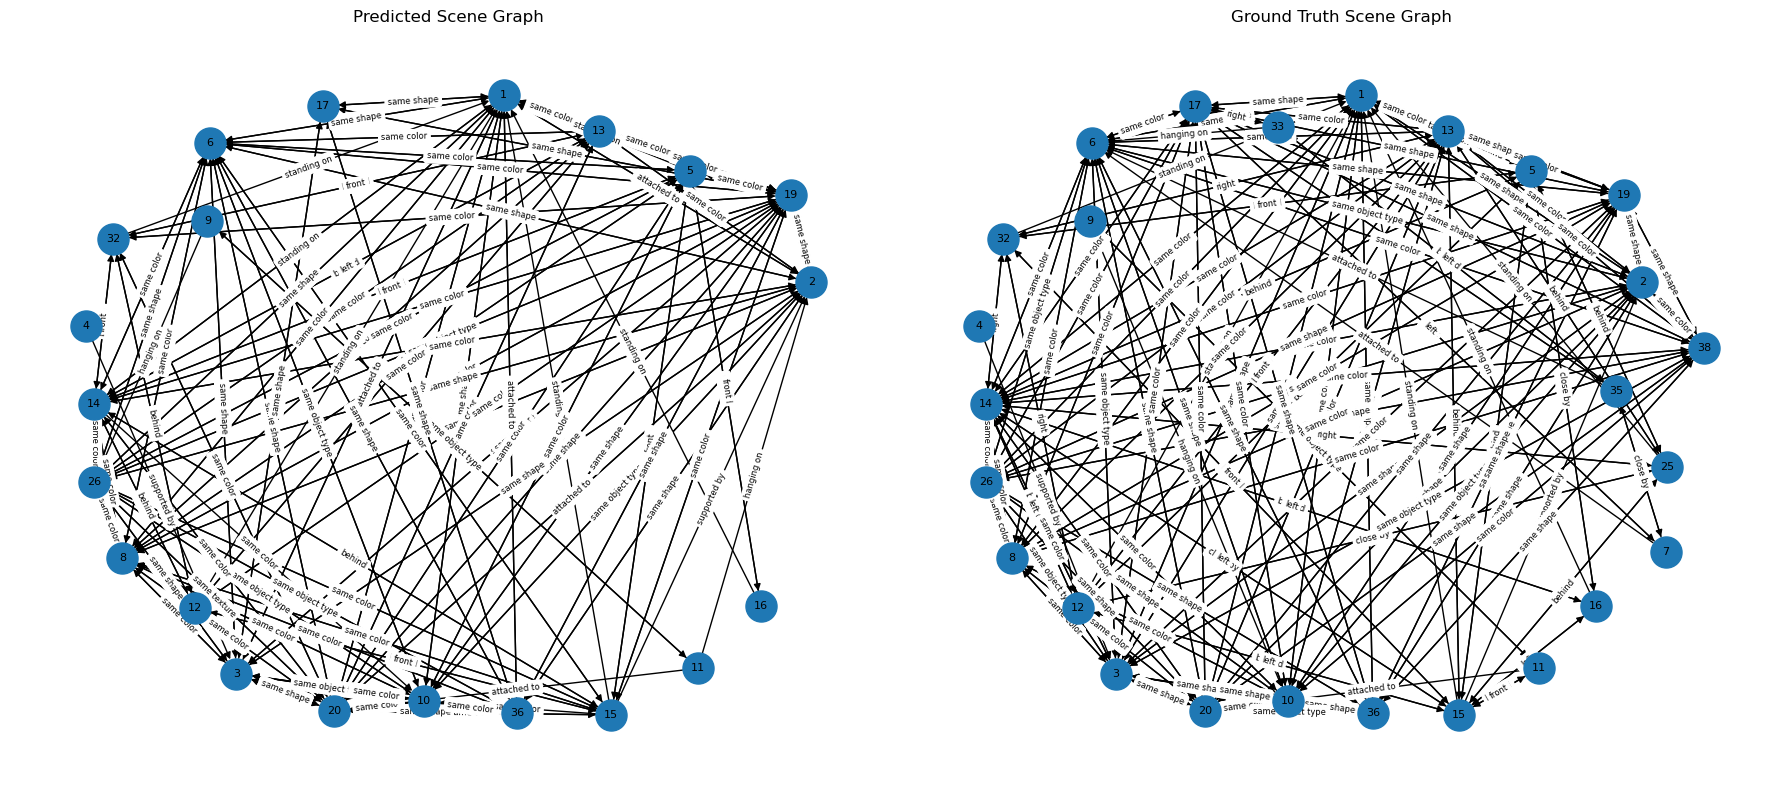

In [56]:
# =========================
# Plot predicted vs ground truth graph
# =========================
import networkx as nx
import matplotlib.pyplot as plt

def build_graph_from_edges(edges):
    G = nx.DiGraph()
    for e in edges:
        G.add_edge(
            int(e["src_object_id"]),
            int(e["dst_object_id"]),
            label=e["relation_name"],
        )
    return G


def build_gt_graph(scan_item):
    G = nx.DiGraph()

    rels = scan_item["relationships"]

    for rel in rels:
        if len(rel) < 3:
            continue

        src, dst, rid = int(rel[0]), int(rel[1]), int(rel[2])
        name = relation_names[rid] if rid < len(relation_names) else str(rid)

        G.add_edge(src, dst, label=name)

    return G


def plot_graphs_side_by_side(scan_item, preds):
    pred_graph = build_graph_from_edges(preds)
    gt_graph = build_gt_graph(scan_item)

    all_nodes = list(set(pred_graph.nodes()).union(set(gt_graph.nodes())))

    pos = nx.spring_layout(all_nodes, seed=42)

    plt.figure(figsize=(18, 8))

    plt.subplot(1, 2, 1)
    nx.draw(pred_graph, pos, with_labels=True, node_size=500, font_size=8, arrows=True)
    nx.draw_networkx_edge_labels(
        pred_graph,
        pos,
        edge_labels=nx.get_edge_attributes(pred_graph, "label"),
        font_size=6,
    )
    plt.title("Predicted Scene Graph")

    plt.subplot(1, 2, 2)
    nx.draw(gt_graph, pos, with_labels=True, node_size=500, font_size=8, arrows=True)
    nx.draw_networkx_edge_labels(
        gt_graph,
        pos,
        edge_labels=nx.get_edge_attributes(gt_graph, "label"),
        font_size=6,
    )
    plt.title("Ground Truth Scene Graph")

    plt.tight_layout()
    plt.show()


scan_item = None
for item in full_dataset:
    if item["scan_id"] == example_scan_id:
        scan_item = item
        break

plot_graphs_side_by_side(scan_item, preds)

In [44]:
for th in [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:
    p, r, f1, tp, fp, fn = compute_metrics(logits, targets, threshold=th)
    print(f"th={th:.2f} P={p:.3f} R={r:.3f} F1={f1:.3f}")

th=0.10 P=0.536 R=0.780 F1=0.635
th=0.15 P=0.659 R=0.712 F1=0.685
th=0.20 P=0.766 R=0.645 F1=0.700
th=0.25 P=0.826 R=0.578 F1=0.680
th=0.30 P=0.863 R=0.523 F1=0.652
th=0.40 P=0.911 R=0.425 F1=0.580
th=0.50 P=0.930 R=0.378 F1=0.538
